# Group 1 – Before and After Data Processing

**Course:** ITAI-1371  
**Group Members:** Tien Manh Nguyen, Viktoriya Kurmisheva, Zaid Alayedy

This separate notebook demonstrates the Patient Health Records dataset **before and after preprocessing**. The raw dataset is used to recreate the same 70/30 train-test split used in the main midterm notebook, while the final clean training CSV represents the processed version.

The comparison focuses on missing values, inconsistent data, identifiers, categorical encoding, City frequency encoding, Blood Pressure preparation, Age preparation, class balancing, and the final machine-learning-ready dataset. The testing dataset remains separate and is not used for preprocessing comparisons.

## 1. Import Libraries

In [43]:
# Import Pandas for working with datasets and DataFrames.
import pandas as pd

# Import NumPy for numerical operations and final validation.
import numpy as np

# Import Matplotlib for before-and-after visualizations.
import matplotlib.pyplot as plt

# Path helps locate the raw and processed CSV files.
from pathlib import Path

# Used to recreate the same 70/30 train-test split
# from the main preprocessing notebook.
from sklearn.model_selection import train_test_split


print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Raw and Clean Datasets

The raw CSV represents the data before preprocessing. The clean CSV is the final processed training dataset exported from the main midterm notebook.

If either file is not already available in the Colab session, the notebook will ask for it.

In [44]:
# Set the expected filenames for the raw and final clean datasets.
raw_path = Path("Patient_Health_Records_Raw.csv")
clean_path = Path("Patient_Health_Records_Clean_Training.csv")



# LOAD RAW DATASET


# If the raw dataset is not already available in Colab,
# ask the user to upload it.
if not raw_path.exists():
    try:
        from google.colab import files

        print("Upload Patient_Health_Records_Raw.csv")
        uploaded = files.upload()

        if not uploaded:
            raise FileNotFoundError(
                "No raw dataset was uploaded."
            )

        # Use the uploaded filename.
        raw_path = Path(
            next(iter(uploaded.keys()))
        )

    except ModuleNotFoundError:
        raise FileNotFoundError(
            "Patient_Health_Records_Raw.csv was not found."
        )


# LOAD CLEAN DATASET


# If the final processed dataset is not already available,
# ask the user to upload it.
if not clean_path.exists():
    try:
        from google.colab import files

        print("Upload Patient_Health_Records_Clean_Training.csv")
        uploaded = files.upload()

        if not uploaded:
            raise FileNotFoundError(
                "No clean dataset was uploaded."
            )

        # Use the uploaded filename.
        clean_path = Path(
            next(iter(uploaded.keys()))
        )

    except ModuleNotFoundError:
        raise FileNotFoundError(
            "Patient_Health_Records_Clean_Training.csv was not found."
        )


# Read both CSV files into Pandas DataFrames.
raw_df = pd.read_csv(raw_path)
clean_df = pd.read_csv(clean_path)


# Display the original dimensions of both datasets.
print("Raw dataset shape:", raw_df.shape)
print("Clean dataset shape:", clean_df.shape)

Raw dataset shape: (10000, 17)
Clean dataset shape: (3518, 31)


## 3. Recreate the Original Training Data

The main project performed the required 70/30 split before EDA. To make the comparison fair, this notebook recreates the same training portion using `random_state=42` and stratification.

Only the minimum target preparation needed for the split is performed here. Records with `Has_Disease` values other than `0` or `1` are excluded before the split, matching the main notebook.

In [45]:
# Create a copy so the original raw dataset remains unchanged.
df_labeled = raw_df.copy()


# Convert Has_Disease to numeric values.
# Values such as "unknown" become missing values.
df_labeled["Has_Disease"] = pd.to_numeric(
    df_labeled["Has_Disease"],
    errors="coerce"
)


# Keep only records with a valid binary target of 0 or 1.
# These are the records that can be used for supervised learning.
df_labeled = df_labeled[
    df_labeled["Has_Disease"].isin([0, 1])
].copy()


# Convert the valid target labels to integers.
df_labeled["Has_Disease"] = (
    df_labeled["Has_Disease"]
    .astype(int)
)


# RECREATE THE SAME 70/30 SPLIT

# Use the same settings as the main preprocessing notebook.
# Stratification keeps the class proportions similar
# in the training and testing datasets.
before_df, test_df_untouched = train_test_split(
    df_labeled,
    test_size=0.30,
    random_state=42,
    stratify=df_labeled["Has_Disease"]
)


# Keep independent copies of both datasets.
before_df = before_df.copy()
test_df_untouched = test_df_untouched.copy()


# Verify the dataset sizes.
print(
    "Before-processing training shape:",
    before_df.shape
)

print(
    "Untouched testing shape:",
    test_df_untouched.shape
)

Before-processing training shape: (3481, 17)
Untouched testing shape: (1493, 17)


## 4. Overall Before and After Comparison

The table below summarizes the main differences between the original training data and the final processed training dataset. The row count increases slightly after processing because random oversampling balances the two `Has_Disease` classes. The increase in duplicate rows after preprocessing is expected because random oversampling balances the minority class by repeating selected training records. These duplicates come from the class-balancing step rather than accidental duplication in the original dataset.

In [46]:
# Identify columns that are not numerical before preprocessing.
before_non_numeric = (
    before_df
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)


# Identify any non-numerical columns remaining
# in the final processed dataset.
after_non_numeric = (
    clean_df
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)


# CREATE BEFORE/AFTER SUMMARY TABLE

# Compare important characteristics of the dataset
# before and after preprocessing.
comparison_summary = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Total Missing Values",
        "Non-Numerical Columns",
        "Duplicate Rows"
    ],

    "Before Processing": [
        before_df.shape[0],
        before_df.shape[1],
        int(before_df.isna().sum().sum()),
        len(before_non_numeric),
        int(before_df.duplicated().sum())
    ],

    "After Processing": [
        clean_df.shape[0],
        clean_df.shape[1],
        int(clean_df.isna().sum().sum()),
        len(after_non_numeric),
        int(clean_df.duplicated().sum())
    ]
})


# Display the overall comparison.
display(comparison_summary)


# Print the actual non-numerical columns for additional detail.
print("\nNon-numerical columns BEFORE:")
print(before_non_numeric)

print("\nNon-numerical columns AFTER:")
print(after_non_numeric)

,Check,Before Processing,After Processing
0,Rows,3481,3518
1,Columns,17,31
2,Total Missing Values,9391,0
3,Non-Numerical Columns,16,0
4,Duplicate Rows,0,678



Non-numerical columns BEFORE:
['Patient_ID', 'Name', 'Age', 'Gender', 'City', 'BMI', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'Diabetic', 'Smoker', 'Medications', 'Last_Visit_Date', 'Follow_Up', 'Diagnosis_Code', 'Notes']

Non-numerical columns AFTER:
[]


## 5. Sample Records Before and After Processing

In [47]:
# Display several records from the original training data
# so the raw formats and values can be seen.
print("Sample BEFORE preprocessing:")

display(
    before_df.head(10)
)


# Display several records from the final processed dataset
# so the numerical machine-learning format can be compared.
print("\nSample AFTER preprocessing:")

display(
    clean_df.head(10)
)

Sample BEFORE preprocessing:


,Patient_ID,Name,Age,Gender,City,BMI,Blood_Pressure,Heart_Rate,Cholesterol_Level,Diabetic,Smoker,Medications,Last_Visit_Date,Follow_Up,Diagnosis_Code,Notes,Has_Disease
5018,ID-05019,John Doe,-5,NaN,Chicago,22.5,NaN,eighty,normal,N,No,"aspirin,metformin",04/11/2022,NaN,B20,Patient feeling fine 🙂,1
9262,ID-09263,Jane Doe,250,M,NY,26.2,131/63,500,NaN,Yes,Former,Lisinopril / Metformin,20201013,NaN,E11.9,NaN,0
3631,ID-03632,"LEE, Sara",29,NaN,Boston,22.5,115/100,500,250,no,No,NaN,Apr 01 2021,two weeks,E11.9,Follow up soon,0
365,ID-00366,michael brown,250,NaN,New York,NaN,120 over 80,0,normal,N,NaN,NaN,18/02/2022,two weeks,I10,NaN,1
8983,ID-08984,Jane Doe,250,F,Boston,22.5,120/80,70,normal,no,NaN,NaN,27/02/2020,two weeks,B20,"BP high, needs recheck",1
7420,ID-07421,michael brown,6,F,newyork,22.5,121/99,500,190,N,NaN,Aspirin; Metformin,2024-08-23,14,B20,NaN,0
900,ID-00901,michael brown,89,M,New York,22.5,120 over 80,eighty,250,N,Former,Lisinopril / Metformin,03/01/2023,two weeks,B20,Follow up soon,0
1293,ID-01294,michael brown,250,male,Boston,22kg/m2,120 - 80,0,NaN,y,NaN,NaN,Feb 13 2022,two weeks,B20,NaN,1
5817,ID-05818,"LEE, Sara",89,male,newyork,19.1,120 - 80,0,high,Unknown,Former,Aspirin; Metformin,17/08/2023,30,I10,Follow up soon,0
7416,ID-07417,michael brown,250,M,Boston,30.4,120 - 80,eighty,normal,Unknown,NaN,NaN,2024-11-30,two weeks,NaN,NaN,0



Sample AFTER preprocessing:


,Age,BMI,Heart_Rate,Cholesterol_Level,Follow_Up,Systolic_BP,Diastolic_BP,Visit_Year,Visit_Month,City_Frequency,...,Medications_Aspirin_Metformin,Medications_Lisinopril_Metformin,Notes_BP_High_Recheck,Notes_Feeling_Fine,Notes_Follow_Up_Soon,Notes_No_Notes,Pulse_Pressure,Mean_Arterial_Pressure,Cholesterol_Age_Ratio,Has_Disease
0,0.659684,0.447518,0.535466,0.0,0.0,0.428571,0.5,2024,5,0.1020,...,1.0,0.0,0.0,1.0,0.0,0.0,0.393939,0.458333,0.288442,1
1,0.705961,0.555262,0.535466,0.0,0.0,0.428571,0.5,2023,2,0.2057,...,1.0,0.0,0.0,0.0,1.0,0.0,0.393939,0.458333,0.243693,0
2,0.659684,0.474038,0.868445,0.0,0.0,0.428571,0.5,2021,8,0.2057,...,1.0,0.0,0.0,0.0,1.0,0.0,0.393939,0.458333,0.288442,0
3,0.388237,0.447518,0.802286,0.0,0.0,0.428571,0.5,2020,8,0.3999,...,0.0,0.0,0.0,0.0,1.0,0.0,0.393939,0.458333,0.582605,0
4,0.705961,0.474038,0.535466,0.0,0.0,0.428571,0.5,2020,6,0.3999,...,1.0,0.0,0.0,0.0,0.0,1.0,0.393939,0.458333,0.243693,1
5,0.705961,0.474038,0.535466,0.0,0.0,0.428571,0.5,2020,9,0.1850,...,0.0,0.0,0.0,0.0,0.0,1.0,0.393939,0.458333,0.243693,0
6,0.388237,0.474038,0.535466,0.0,0.0,0.428571,0.5,2023,4,0.3999,...,1.0,0.0,1.0,0.0,0.0,0.0,0.393939,0.458333,0.582605,0
7,0.995666,0.474038,0.755982,0.0,0.0,0.428571,0.5,2025,2,0.2057,...,1.0,0.0,1.0,0.0,0.0,0.0,0.393939,0.458333,0.002978,0
8,0.705961,0.474038,0.670205,0.0,0.0,0.428571,0.5,2022,12,0.2057,...,1.0,0.0,1.0,0.0,0.0,0.0,0.393939,0.458333,0.243693,0
9,0.388237,0.447518,0.535466,0.0,0.0,0.428571,0.5,2023,7,0.3999,...,0.0,1.0,0.0,0.0,0.0,1.0,0.393939,0.458333,0.582605,1


## 6. Missing Values Before and After

The raw training data contains many missing values across numerical, categorical, and text columns. The final processed dataset should contain no missing values.

Missing values BEFORE preprocessing:


,Missing Before
Notes,1401
Medications,1381
Smoker,1123
Follow_Up,880
BMI,838
Cholesterol_Level,741
Blood_Pressure,727
Gender,594
Diabetic,591
Diagnosis_Code,580



Total missing values AFTER preprocessing:
0


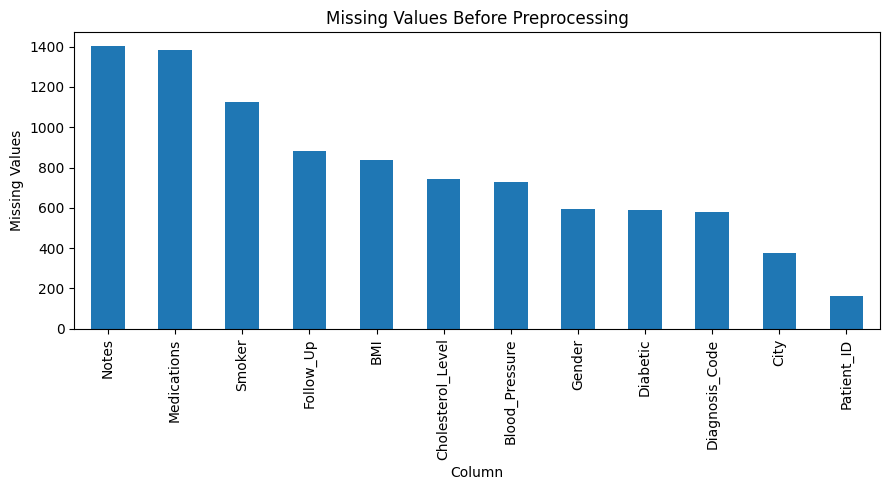

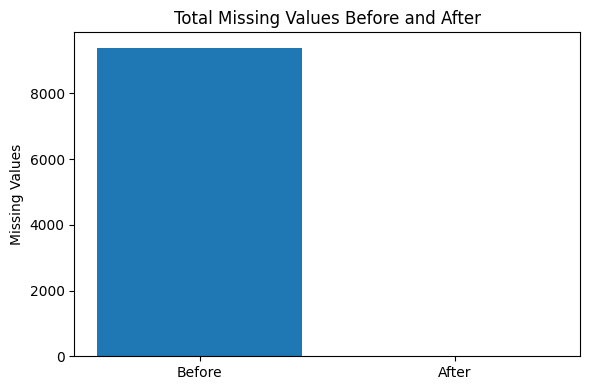

In [48]:
# Count missing values in every column before preprocessing.
missing_before = (
    before_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)


# Count missing values in the final clean dataset.
missing_after = (
    clean_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)



# DISPLAY MISSING-VALUE COUNTS


print("Missing values BEFORE preprocessing:")

display(
    pd.DataFrame({
        "Missing Before": missing_before
    })
)


print(
    "\nTotal missing values AFTER preprocessing:"
)

print(
    int(missing_after.sum())
)


# VISUALIZE MISSING VALUES BEFORE PREPROCESSING

# Plot only columns that originally contained missing values.
plt.figure(figsize=(9, 5))

missing_before[
    missing_before > 0
].plot(kind="bar")

plt.title("Missing Values Before Preprocessing")
plt.xlabel("Column")
plt.ylabel("Missing Values")
plt.tight_layout()
plt.show()


# COMPARE TOTAL MISSING VALUES BEFORE AND AFTER

plt.figure(figsize=(6, 4))

plt.bar(
    ["Before", "After"],
    [
        before_df.isna().sum().sum(),
        clean_df.isna().sum().sum()
    ]
)

plt.title("Total Missing Values Before and After")
plt.ylabel("Missing Values")
plt.tight_layout()
plt.show()

## 7. Identifying Fields Before and After

`Patient_ID` and `Name` appear in the original training data but are removed from the final processed dataset because they identify individual patients rather than describe health patterns. `Diagnosis_Code` is also removed because it may contain information too closely related to the target.

In [49]:
# These columns were intentionally removed during preprocessing.
removed_columns = [
    "Patient_ID",
    "Name",
    "Diagnosis_Code"
]


# Check whether each column existed before preprocessing
# and whether it remains in the final clean dataset.
identifier_check = pd.DataFrame({
    "Column": removed_columns,

    "Present Before": [
        column in before_df.columns
        for column in removed_columns
    ],

    "Present After": [
        column in clean_df.columns
        for column in removed_columns
    ]
})


# Display the comparison.
display(identifier_check)

,Column,Present Before,Present After
0,Patient_ID,True,False
1,Name,True,False
2,Diagnosis_Code,True,False


## 8. Age Before and After

The raw `Age` column contains inconsistent values such as `twenty`, `-5`, and `250`. In the main preprocessing notebook, known formatting problems are corrected, the feature is converted to numerical form, and later normalization and scaling prepare it for machine learning.

Because the final CSV contains the scaled version of Age, its values are between `0` and `1` rather than the original age units.

Most common raw Age values BEFORE preprocessing:


,count
Age,
-5,904
twenty,851
250,841
6,19
5,19
71,17
10,16
75,15
72,15



Age summary AFTER preprocessing and scaling:
count    3518.000000
mean        0.628268
std         0.179861
min         0.000000
25%         0.388237
50%         0.659684
75%         0.705961
max         1.000000
Name: Age, dtype: float64

Final Age range:
Minimum: 0.0
Maximum: 1.0


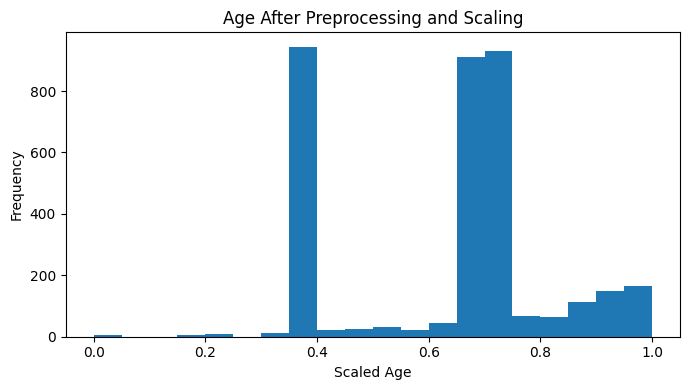

In [50]:

# AGE BEFORE PREPROCESSING

# Display the most common raw Age values.
# This reveals inconsistent entries such as -5, 250, and twenty.
print(
    "Most common raw Age values BEFORE preprocessing:"
)

display(
    before_df["Age"]
    .value_counts(dropna=False)
    .head(15)
)


# AGE AFTER PREPROCESSING

# Display summary statistics for the final processed Age feature.
# The final Age values have already been normalized and scaled.
print(
    "\nAge summary AFTER preprocessing and scaling:"
)

print(
    clean_df["Age"].describe()
)


# Verify the final scaled range.
print("\nFinal Age range:")

print(
    "Minimum:",
    clean_df["Age"].min()
)

print(
    "Maximum:",
    clean_df["Age"].max()
)


# Visualize the processed Age distribution.
plt.figure(figsize=(7, 4))

plt.hist(
    clean_df["Age"],
    bins=20
)

plt.title("Age After Preprocessing and Scaling")
plt.xlabel("Scaled Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 9. City Before and After

The raw City column contains several inconsistent spellings and abbreviations. In the final dataset, City is standardized and represented with one `City_Frequency` column instead of creating a separate One-Hot column for every city.

In [51]:
# CITY BEFORE PREPROCESSING

# Display all City values and their frequencies
# before cleaning and encoding.
print("City values BEFORE preprocessing:")

display(
    before_df["City"]
    .value_counts(dropna=False)
)


# CITY AFTER PREPROCESSING

# The original City text column should no longer exist.
print(
    "\nCity representation AFTER preprocessing:"
)

print(
    "City column present:",
    "City" in clean_df.columns
)


# City should now appear as one frequency-encoded column.
print(
    "City_Frequency present:",
    "City_Frequency" in clean_df.columns
)


# Display the different frequency values
# that represent the standardized City categories.
if "City_Frequency" in clean_df.columns:

    print(
        "\nUnique City_Frequency values:"
    )

    print(
        sorted(
            clean_df["City_Frequency"]
            .dropna()
            .unique()
        )
    )

City values BEFORE preprocessing:


,count
City,
Chicago,377
NaN,374
NY,364
Boston,355
la,353
New York,352
Nwe Yrok,344
chicago,339
newyork,332



City representation AFTER preprocessing:
City column present: False
City_Frequency present: True

Unique City_Frequency values:
[np.float64(0.102), np.float64(0.1074), np.float64(0.185), np.float64(0.2057), np.float64(0.3999)]


## 10. Blood Pressure Before and After

The raw `Blood_Pressure` feature contains text values with different separators. The preprocessing workflow standardizes those formats, splits the measurement into `Systolic_BP` and `Diastolic_BP`, checks invalid relationships, and handles missing values before later feature engineering and scaling.

In [52]:
# BLOOD PRESSURE BEFORE PREPROCESSING

# Display raw Blood Pressure values.
# The original column contains text and different separators.
print(
    "Sample Blood Pressure values BEFORE preprocessing:"
)

display(
    before_df[
        ["Blood_Pressure"]
    ].head(15)
)


# BLOOD PRESSURE AFTER PREPROCESSING

# Identify the final numerical Blood Pressure features
# that exist in the processed dataset.
bp_after_columns = [
    column
    for column in [
        "Systolic_BP",
        "Diastolic_BP",
        "Pulse_Pressure",
        "Mean_Arterial_Pressure"
    ]
    if column in clean_df.columns
]


# Display the processed Blood Pressure features.
print(
    "\nBlood Pressure features AFTER preprocessing:"
)

# Display a reproducible sample of processed Blood Pressure values
# so different numerical values can be seen.
display(
    clean_df[
        bp_after_columns
    ].sample(
        15,
        random_state=42
    )
)


# Verify that the original text Blood_Pressure column
# was removed from the final dataset.
print(
    "\nOriginal Blood_Pressure column "
    "present after processing:"
)

print(
    "Blood_Pressure" in clean_df.columns
)

Sample Blood Pressure values BEFORE preprocessing:


,Blood_Pressure
5018,NaN
9262,131/63
3631,115/100
365,120 over 80
8983,120/80
7420,121/99
900,120 over 80
1293,120 - 80
5817,120 - 80
7416,120 - 80



Blood Pressure features AFTER preprocessing:


,Systolic_BP,Diastolic_BP,Pulse_Pressure,Mean_Arterial_Pressure
2457,0.614286,0.075,0.696970,0.312500
70,0.428571,0.500,0.393939,0.458333
358,0.428571,0.500,0.393939,0.458333
325,0.428571,0.500,0.393939,0.458333
2208,0.428571,0.500,0.393939,0.458333
298,0.428571,0.500,0.393939,0.458333
976,0.428571,0.500,0.393939,0.458333
1457,0.428571,0.500,0.393939,0.458333
291,0.428571,0.450,0.414141,0.430556
2183,0.428571,0.500,0.393939,0.458333



Original Blood_Pressure column present after processing:
False


## 11. Categorical Encoding Before and After

The original training data contains text-based categorical variables. After preprocessing, Gender, Diabetic status, Smoker status, Medications, and Notes are represented numerically with One-Hot Encoding, while City uses frequency encoding.

In [53]:
# List the original categorical and text features.
categorical_original = [
    "Gender",
    "City",
    "Diabetic",
    "Smoker",
    "Medications",
    "Notes"
]


# CHECK ORIGINAL TEXT FEATURES


# Compare whether the original categorical columns
# appear before and after preprocessing.
encoding_summary = pd.DataFrame({
    "Original Feature": categorical_original,

    "Present as Text Before": [
        column in before_df.columns
        for column in categorical_original
    ],

    "Present as Text After": [
        column in clean_df.columns
        for column in categorical_original
    ]
})


display(encoding_summary)


# FIND ONE-HOT ENCODED FEATURES

# Identify the final One-Hot Encoded columns.
# City is excluded because it uses frequency encoding instead.
encoded_columns = [
    column
    for column in clean_df.columns
    if column.startswith((
        "Gender_",
        "Diabetic_",
        "Smoker_",
        "Medications_",
        "Notes_"
    ))
]


print(
    "\nEncoded columns in the final dataset:"
)

print(encoded_columns)


# Verify the separate frequency-encoded City feature.
print("\nCity frequency column:")

print(
    "City_Frequency" in clean_df.columns
)

,Original Feature,Present as Text Before,Present as Text After
0,Gender,True,False
1,City,True,False
2,Diabetic,True,False
3,Smoker,True,False
4,Medications,True,False
5,Notes,True,False



Encoded columns in the final dataset:
['Gender_Female', 'Gender_Male', 'Gender_Unknown', 'Diabetic_No', 'Diabetic_Unknown', 'Diabetic_Yes', 'Smoker_Former', 'Smoker_No', 'Smoker_Unknown', 'Smoker_Yes', 'Medications_0', 'Medications_Aspirin_Metformin', 'Medications_Lisinopril_Metformin', 'Notes_BP_High_Recheck', 'Notes_Feeling_Fine', 'Notes_Follow_Up_Soon', 'Notes_No_Notes']

City frequency column:
True


## 12. Class Distribution Before and After Balancing

The training classes are close in size before processing, but the project demonstrates class balancing through random oversampling. The final processed training dataset contains an equal number of records for classes `0` and `1`.

,Before Balancing,After Balancing
Has_Disease,,
0,1759,1759
1,1722,1759


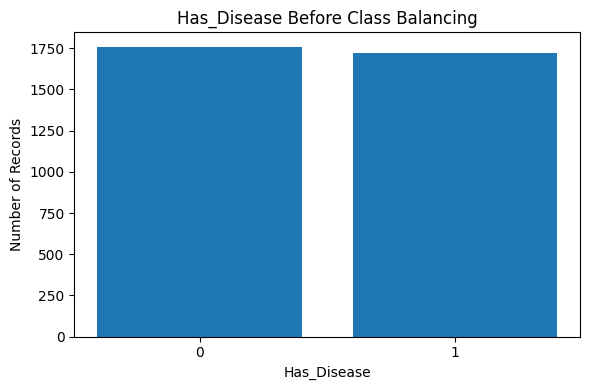

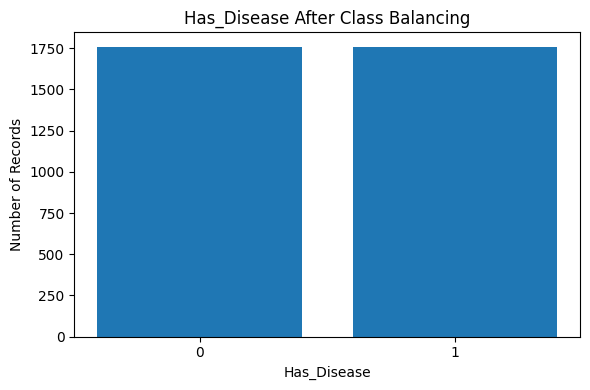

In [54]:
# Count each Has_Disease class before balancing.
class_before = (
    before_df["Has_Disease"]
    .value_counts()
    .sort_index()
)


# Count each Has_Disease class
# in the final balanced training dataset.
class_after = (
    clean_df["Has_Disease"]
    .value_counts()
    .sort_index()
)


# CREATE BEFORE/AFTER CLASS TABLE

class_comparison = pd.DataFrame({
    "Before Balancing": class_before,
    "After Balancing": class_after
})


display(class_comparison)


# VISUALIZE CLASS DISTRIBUTION BEFORE BALANCING

plt.figure(figsize=(6, 4))

plt.bar(
    class_before.index.astype(str),
    class_before.values
)

plt.title("Has_Disease Before Class Balancing")
plt.xlabel("Has_Disease")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


# VISUALIZE CLASS DISTRIBUTION AFTER BALANCING

plt.figure(figsize=(6, 4))

plt.bar(
    class_after.index.astype(str),
    class_after.values
)

plt.title("Has_Disease After Class Balancing")
plt.xlabel("Has_Disease")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## 13. Final Processed Dataset Verification

The final checks confirm that the processed training dataset contains numerical features only, no missing values, and no infinite values. The balanced target is included in the final CSV.

In [55]:

# CHECK FOR MISSING VALUES

# Count all remaining missing values.
final_missing = int(
    clean_df
    .isna()
    .sum()
    .sum()
)


# CHECK FOR NON-NUMERICAL FEATURES

# A machine-learning-ready dataset should contain
# numerical features only.
final_non_numeric = (
    clean_df
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)


# CHECK FOR INFINITE VALUES

# Check the numerical data for positive or negative infinity.
final_infinite = int(
    np.isinf(
        clean_df
        .select_dtypes(include=["number"])
        .to_numpy()
    ).sum()
)


# DISPLAY FINAL RESULTS

print(
    "Final dataset shape:",
    clean_df.shape
)

print(
    "Missing values:",
    final_missing
)

print(
    "Non-numerical columns:",
    final_non_numeric
)

print(
    "Infinite values:",
    final_infinite
)


# Verify the final balanced target distribution.
print(
    "\nFinal Has_Disease distribution:"
)

print(
    clean_df["Has_Disease"]
    .value_counts()
    .sort_index()
)

Final dataset shape: (3518, 31)
Missing values: 0
Non-numerical columns: []
Infinite values: 0

Final Has_Disease distribution:
Has_Disease
0    1759
1    1759
Name: count, dtype: int64


## Conclusion

The comparison shows how the raw training data changes after the complete preprocessing workflow. Before processing, the dataset contains missing values, inconsistent text and numerical formats, identifying fields, mixed data types, and an unequal target distribution. After processing, the final training dataset contains only numerical features, no missing or infinite values, cleaned and encoded categorical information, engineered health features, scaled continuous variables, and balanced `Has_Disease` classes.

This notebook demonstrates the before-and-after results without repeating the full preprocessing code from the main midterm notebook. The final clean dataset is ready for future binary classification work, while the testing dataset remains separate for later model evaluation.